# K-Nearest Neighbors ExperimentsThis notebook documents all KNN experiments on the fraud detection dataset.Each experiment is run on **two feature sets** to compare the effect of feature selection:| Label | Source | Features ||-------|--------|----------|| **Partially Selected (PS)** | `data/processed/partially_selected_features.csv` | 37 columns (36 features + target) || **Selected / MRMR** | `data/processed/selected_features.csv` | 18 columns (17 features + target) |**Preprocessing pipeline (updated):**1. One-hot encoding for categorical features (via `pd.get_dummies`)2. Stratified train/val/test split (70/15/15)3. StandardScaler fit on train only4. SMOTE comparison after hyperparameter tuning**Experiments:**1. Baseline KNN (K=5)2. Cross-validation stability check3. K tuning with threshold optimization4. Weighting scheme (uniform vs distance)5. Distance metric (Euclidean vs Manhattan)6. Best config with CV confirmation7. Threshold tuning8. SMOTE comparison9. Final test evaluation + model saving

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.data.load_data import load_selected_features
from src.models.predict import predict, predict_proba
from src.evaluation.metrics import evaluate_model, print_metrics

print('Imports loaded successfully.')

Imports loaded successfully.


## Data PreparationWe load both feature sets and apply the same preprocessing pipeline:1. **One-hot encoding** for categorical features — `pd.get_dummies()` on training data, then align val/test columns2. **Stratified train/val/test split** — 70/15/15 ratio, preserving class balance in each set3. **Standard scaling** — fit on train, transform all sets

In [2]:
def prepare_dataset(path, label):
    df = load_selected_features(path)
    print(f"\n{'='*60}")
    print(f"{label} -- {path}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"Class distribution:\n{df['fraud_reported'].value_counts()}")
    print(f"Fraud rate: {(df['fraud_reported'] == 'Y').mean()*100:.1f}%")

    # Encode target
    y = (df['fraud_reported'] == 'Y').astype(int)
    X = df.drop(columns=['fraud_reported'])

    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical features ({len(num_cols)}): {num_cols}")

    # Stratified 70/15/15 split BEFORE encoding
    X_train_raw, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    X_val_raw, X_test_raw, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    # One-hot encode: fit on train, align val/test
    X_train_ohe = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=False)
    train_cols = X_train_ohe.columns.tolist()

    X_val_ohe = pd.get_dummies(X_val_raw, columns=cat_cols, drop_first=False)
    X_val_ohe = X_val_ohe.reindex(columns=train_cols, fill_value=0)

    X_test_ohe = pd.get_dummies(X_test_raw, columns=cat_cols, drop_first=False)
    X_test_ohe = X_test_ohe.reindex(columns=train_cols, fill_value=0)

    print(f"\nAfter one-hot encoding: {X_train_ohe.shape[1]} features")

    # Standard scaling: fit on train only
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_ohe)
    X_val_s = scaler.transform(X_val_ohe)
    X_test_s = scaler.transform(X_test_ohe)

    print(f"Train: {X_train_s.shape[0]}  |  Val: {X_val_s.shape[0]}  |  Test: {X_test_s.shape[0]}")
    print(f"Scaling: fit on train, transformed all sets")

    return {
        'X_train': X_train_s, 'X_val': X_val_s, 'X_test': X_test_s,
        'y_train': y_train.values, 'y_val': y_val.values, 'y_test': y_test.values,
        'scaler': scaler, 'label': label,
        'feature_names': train_cols,
    }

ds_ps = prepare_dataset('../data/processed/partially_selected_features.csv', 'Partially Selected (PS)')
ds_s  = prepare_dataset('../data/processed/selected_features.csv', 'Selected / MRMR')

datasets = [ds_ps, ds_s]


Partially Selected (PS) -- ../data/processed/partially_selected_features.csv
Shape: (1000, 37)
Class distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64
Fraud rate: 24.7%

Categorical features (17): ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
Numerical features (19): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'policy_tenure_days', 'incident_day_of_week', 'incident_month']

After one-hot encoding: 162 features
Train: 700  |  Val: 1

In [3]:
# Utility: find the threshold that maximizes F1 on a given set
def find_best_threshold(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        if yp.sum() == 0 or yp.sum() == len(yp):
            continue
        f = f1_score(y_true, yp)
        if f > best_f1:
            best_t, best_f1 = t, f
    return best_t, best_f1

---## Run 1: Baseline KNN (K=5)**Goal:** Establish a baseline with the most common default: K=5, uniform weights, Euclidean distance.**Configuration:**- `n_neighbors=5` -- a common default. Each sample is classified by the majority vote of its 5  nearest neighbors in the scaled feature space.- `weights='uniform'` -- all neighbors contribute equally.- `metric='euclidean'` -- standard L2 distance.

In [4]:
for ds in datasets:
    model = KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='euclidean', n_jobs=-1
    )
    model.fit(ds['X_train'], ds['y_train'])
    ds['model_v1'] = model
    ds['results_log'] = []

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_pred = predict(model, X_set)
        y_prob = predict_proba(model, X_set)
        res = evaluate_model(y_set, y_pred, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v1'] = res

    ds['results_log'].append({
        'Run': 'V1: Baseline (K=5, uniform, euclidean)',
        'Val F1': ds['val_res_v1']['f1'],
        'Val Precision': ds['val_res_v1']['precision'],
        'Val Recall': ds['val_res_v1']['recall'],
        'Val ROC AUC': ds['val_res_v1']['roc_auc'],
    })


Partially Selected (PS)
[Train] Accuracy:  0.8000
[Train] Precision: 0.6988
[Train] Recall:    0.3353
[Train] F1 Score:  0.4531
[Train] ROC AUC:   0.8359

[Validation] Accuracy:  0.7400
[Validation] Precision: 0.4375
[Validation] Recall:    0.1892
[Validation] F1 Score:  0.2642
[Validation] ROC AUC:   0.6332


Selected / MRMR
[Train] Accuracy:  0.8200
[Train] Precision: 0.8052
[Train] Recall:    0.3584
[Train] F1 Score:  0.4960
[Train] ROC AUC:   0.8590

[Validation] Accuracy:  0.7200
[Validation] Precision: 0.3684
[Validation] Recall:    0.1892
[Validation] F1 Score:  0.2500
[Validation] ROC AUC:   0.6044



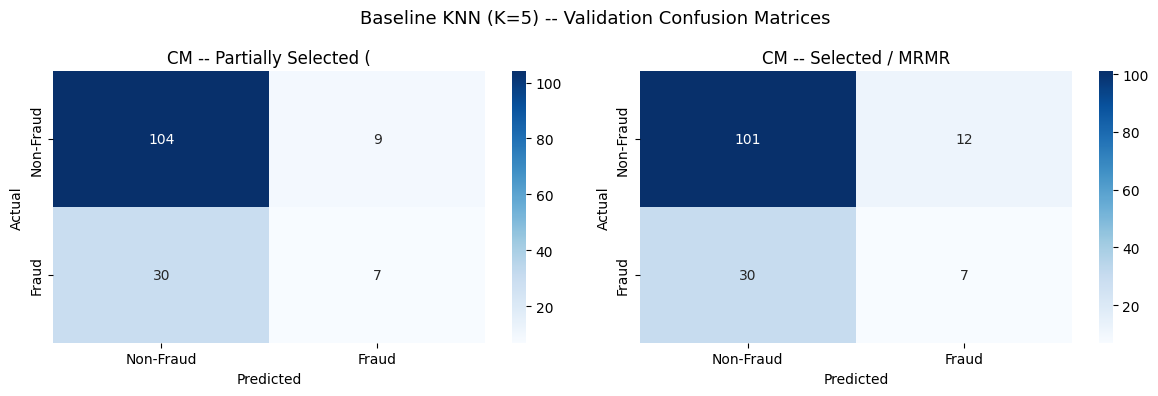

In [5]:
# Confusion matrices -- baseline, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds in zip(axes, datasets):
    y_pred = predict(ds['model_v1'], ds['X_val'])
    cm = confusion_matrix(ds['y_val'], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f'CM -- {ds["label"][:20]}')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Baseline KNN (K=5) -- Validation Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

---## Run 2: Cross-Validation to Assess Stability**Goal:** Assess how stable the baseline KNN is across different data folds.**Method:** 5-fold stratified CV on the training set.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ds in datasets:
    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")

    cv_model = KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='euclidean', n_jobs=-1
    )
    for metric in ['f1', 'roc_auc']:
        scores = cross_val_score(cv_model, ds['X_train'], ds['y_train'], cv=cv, scoring=metric)
        print(f"CV {metric}: {scores.mean():.4f} (+/- {scores.std():.4f})  {scores.round(4)}")


Partially Selected (PS)
CV f1: 0.2199 (+/- 0.0362)  [0.2273 0.1702 0.28   0.2222 0.2   ]
CV roc_auc: 0.5931 (+/- 0.0385)  [0.6561 0.5988 0.5943 0.5804 0.5362]

Selected / MRMR
CV f1: 0.1775 (+/- 0.0556)  [0.2174 0.0952 0.1887 0.25   0.1364]
CV roc_auc: 0.5970 (+/- 0.0471)  [0.6325 0.6701 0.542  0.5709 0.5693]


---## Run 3: K Tuning (n_neighbors) with Threshold Optimization**Goal:** Find the optimal K value.**Why joint K + threshold tuning?** At the default threshold of 0.5, KNN on imbalanced dataheavily favors the majority class. With K=5, a sample needs 3+ fraud neighbors to be classifiedas fraud -- unlikely when fraud is rare. Tuning the threshold alongside K lets us find thesweet spot between precision and recall for each K.

In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

for ds in datasets:
    k_results = []
    best_k, best_k_f1, best_k_t = 5, 0, 0.5

    for k in k_values:
        model_k = KNeighborsClassifier(
            n_neighbors=k, weights='uniform', metric='euclidean', n_jobs=-1
        )
        model_k.fit(ds['X_train'], ds['y_train'])

        y_pred_val = predict(model_k, ds['X_val'])
        y_prob_val = predict_proba(model_k, ds['X_val'])
        val_res = evaluate_model(ds['y_val'], y_pred_val, y_prob_val)

        y_pred_train = predict(model_k, ds['X_train'])
        train_f1 = f1_score(ds['y_train'], y_pred_train)

        # Find best threshold for this K
        bt, bf = find_best_threshold(ds['y_val'], y_prob_val)
        if bf > best_k_f1:
            best_k, best_k_f1, best_k_t = k, bf, bt

        k_results.append({
            'K': k,
            'Train F1': train_f1,
            'Val F1 (t=0.5)': val_res['f1'],
            'Best Threshold': bt,
            'Val F1 (tuned)': bf,
            'Val ROC AUC': val_res['roc_auc'],
        })

    k_df = pd.DataFrame(k_results)
    ds['k_df'] = k_df
    ds['best_k'] = best_k
    ds['best_k_t'] = best_k_t

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(k_df.to_string(index=False))
    print(f"\nBest K={best_k} at threshold={best_k_t:.2f} (Val F1={best_k_f1:.4f})")


Partially Selected (PS)
 K  Train F1  Val F1 (t=0.5)  Best Threshold  Val F1 (tuned)  Val ROC AUC
 1  1.000000        0.282353            0.05        0.282353     0.502870
 3  0.557143        0.323529            0.05        0.388060     0.569242
 5  0.453125        0.264151            0.25        0.446809     0.633222
 7  0.357143        0.227273            0.15        0.422764     0.621741
 9  0.269231        0.093023            0.25        0.421053     0.581559
11  0.157895        0.100000            0.05        0.393443     0.523320
15  0.118280        0.100000            0.25        0.400000     0.570079
21  0.066667        0.052632            0.15        0.426667     0.629156
31  0.022857        0.000000            0.25        0.480000     0.679024
51  0.000000        0.000000            0.20        0.557377     0.756159

Best K=51 at threshold=0.20 (Val F1=0.5574)



Selected / MRMR
 K  Train F1  Val F1 (t=0.5)  Best Threshold  Val F1 (tuned)  Val ROC AUC
 1  1.000000        0.246914            0.05        0.246914     0.484693
 3  0.619718        0.258065            0.05        0.373984     0.543650
 5  0.496000        0.250000            0.25        0.413793     0.604401
 7  0.352423        0.163265            0.05        0.397590     0.595432
 9  0.222222        0.133333            0.15        0.410959     0.583951
11  0.125000        0.136364            0.10        0.402516     0.584908
15  0.095745        0.146341            0.15        0.410596     0.564817
21  0.087912        0.052632            0.15        0.434211     0.649845
31  0.087912        0.000000            0.25        0.480769     0.693614
51  0.044944        0.000000            0.20        0.544000     0.789404

Best K=51 at threshold=0.20 (Val F1=0.5440)


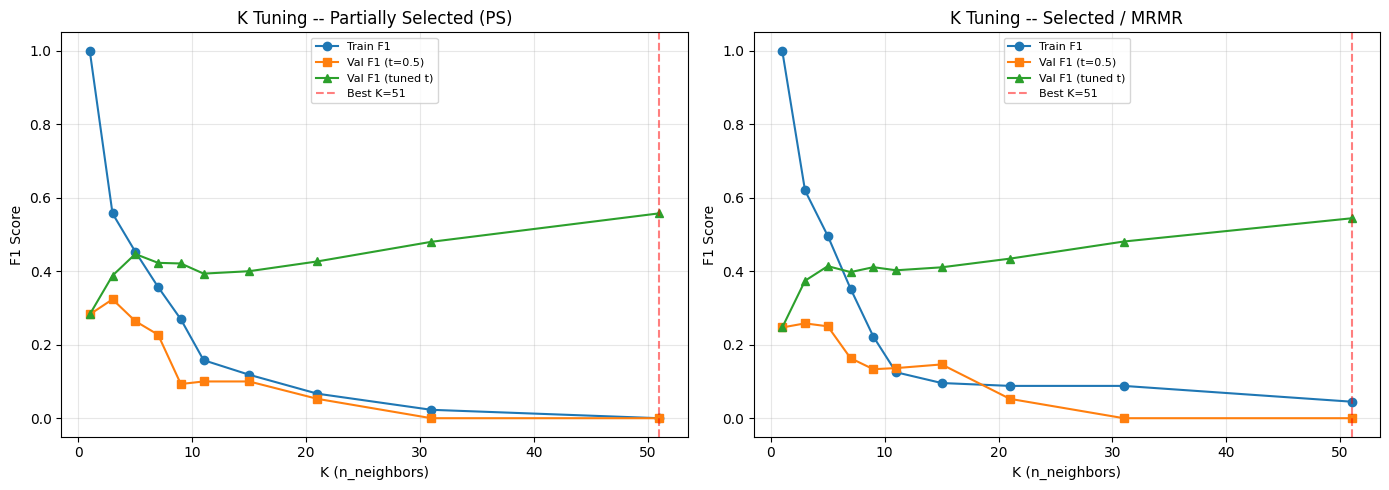

In [8]:
# Visualize K tuning -- both feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    k_df = ds['k_df']
    ax.plot(k_df['K'], k_df['Train F1'], 'o-', label='Train F1')
    ax.plot(k_df['K'], k_df['Val F1 (t=0.5)'], 's-', label='Val F1 (t=0.5)')
    ax.plot(k_df['K'], k_df['Val F1 (tuned)'], '^-', label='Val F1 (tuned t)')
    ax.axvline(x=ds['best_k'], color='red', linestyle='--', alpha=0.5, label=f'Best K={ds["best_k"]}')
    ax.set_xlabel('K (n_neighbors)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'K Tuning -- {ds["label"]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---## Run 4: Weighting Scheme (uniform vs distance)**Goal:** Test whether distance-weighted voting improves over uniform voting.**Why distance weighting?** With `weights='distance'`, closer neighbors have more influenceon the vote than farther ones. This can help when the K nearest neighbors span a large rangeof distances.

In [9]:
for ds in datasets:
    best_w, best_w_f1, best_w_t = 'uniform', 0, 0.5

    print(f"\n{'='*60}")
    print(f"{ds['label']} (K={ds['best_k']})")
    print(f"{'='*60}")

    for w in ['uniform', 'distance']:
        m = KNeighborsClassifier(
            n_neighbors=ds['best_k'], weights=w, metric='euclidean', n_jobs=-1
        )
        m.fit(ds['X_train'], ds['y_train'])
        r = evaluate_model(ds['y_val'], predict(m, ds['X_val']), predict_proba(m, ds['X_val']))
        y_prob_val = predict_proba(m, ds['X_val'])
        bt, bf = find_best_threshold(ds['y_val'], y_prob_val)
        if bf > best_w_f1:
            best_w, best_w_f1, best_w_t = w, bf, bt
        print(f"  {w:<10}: Val F1(t=0.5)={r['f1']:.4f}  Val F1(t={bt:.2f})={bf:.4f}  AUC={r['roc_auc']:.4f}")

    ds['best_w'] = best_w
    print(f"  Best weights: {best_w}")


Partially Selected (PS) (K=51)
  uniform   : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5574  AUC=0.7562


  distance  : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5397  AUC=0.7532
  Best weights: uniform

Selected / MRMR (K=51)
  uniform   : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5440  AUC=0.7894
  distance  : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5354  AUC=0.7821
  Best weights: uniform


---## Run 5: Distance Metric (Euclidean vs Manhattan)**Goal:** Test whether Manhattan distance outperforms Euclidean.**Why Manhattan?** Euclidean distance is sensitive to outliers (squared differences amplifylarge deviations). Manhattan distance (sum of absolute differences) is more robust.Additionally, in high-dimensional spaces (many one-hot features), Manhattan can sometimesperform better.

In [10]:
for ds in datasets:
    best_met, best_met_f1, best_met_t = 'euclidean', 0, 0.5

    print(f"\n{'='*60}")
    print(f"{ds['label']} (K={ds['best_k']}, weights={ds['best_w']})")
    print(f"{'='*60}")

    for met in ['euclidean', 'manhattan']:
        m = KNeighborsClassifier(
            n_neighbors=ds['best_k'], weights=ds['best_w'], metric=met, n_jobs=-1
        )
        m.fit(ds['X_train'], ds['y_train'])
        r = evaluate_model(ds['y_val'], predict(m, ds['X_val']), predict_proba(m, ds['X_val']))
        y_prob_val = predict_proba(m, ds['X_val'])
        bt, bf = find_best_threshold(ds['y_val'], y_prob_val)
        if bf > best_met_f1:
            best_met, best_met_f1, best_met_t = met, bf, bt
        print(f"  {met:<12}: Val F1(t=0.5)={r['f1']:.4f}  Val F1(t={bt:.2f})={bf:.4f}  AUC={r['roc_auc']:.4f}")

    ds['best_met'] = best_met
    print(f"  Best metric: {best_met}")


Partially Selected (PS) (K=51, weights=uniform)
  euclidean   : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5574  AUC=0.7562
  manhattan   : Val F1(t=0.5)=0.0000  Val F1(t=0.30)=0.6479  AUC=0.8252
  Best metric: manhattan

Selected / MRMR (K=51, weights=uniform)
  euclidean   : Val F1(t=0.5)=0.0000  Val F1(t=0.20)=0.5440  AUC=0.7894


  manhattan   : Val F1(t=0.5)=0.0526  Val F1(t=0.30)=0.7200  AUC=0.8692
  Best metric: manhattan


---## Run 6: Best Configuration with CV Confirmation**Goal:** Confirm the best hyperparameters found in Runs 3-5 via cross-validation.**Method:** 5-fold stratified CV with the best K, weights, and distance metric.

In [11]:
for ds in datasets:
    model_v2 = KNeighborsClassifier(
        n_neighbors=ds['best_k'], weights=ds['best_w'], metric=ds['best_met'], n_jobs=-1
    )

    cv_f1 = cross_val_score(model_v2, ds['X_train'], ds['y_train'], cv=cv, scoring='f1')
    cv_auc = cross_val_score(model_v2, ds['X_train'], ds['y_train'], cv=cv, scoring='roc_auc')

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(f"Config: K={ds['best_k']}, weights={ds['best_w']}, metric={ds['best_met']}")
    print(f"CV F1 (default threshold): {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    print(f"CV ROC AUC: {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")

    model_v2.fit(ds['X_train'], ds['y_train'])
    ds['model_v2'] = model_v2

    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_pred = predict(model_v2, X_set)
        y_prob = predict_proba(model_v2, X_set)
        res = evaluate_model(y_set, y_pred, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v2'] = res

    ds['results_log'].append({
        'Run': f'V2: Tuned (K={ds["best_k"]}, {ds["best_w"]}, {ds["best_met"]})',
        'Val F1': ds['val_res_v2']['f1'],
        'Val Precision': ds['val_res_v2']['precision'],
        'Val Recall': ds['val_res_v2']['recall'],
        'Val ROC AUC': ds['val_res_v2']['roc_auc'],
    })


Partially Selected (PS)
Config: K=51, weights=uniform, metric=manhattan
CV F1 (default threshold): 0.0000 (+/- 0.0000)
CV ROC AUC: 0.7804 (+/- 0.0488)
[Train] Accuracy:  0.7543
[Train] Precision: 1.0000
[Train] Recall:    0.0058
[Train] F1 Score:  0.0115
[Train] ROC AUC:   0.8191

[Validation] Accuracy:  0.7533
[Validation] Precision: 0.0000
[Validation] Recall:    0.0000
[Validation] F1 Score:  0.0000
[Validation] ROC AUC:   0.8252




Selected / MRMR
Config: K=51, weights=uniform, metric=manhattan
CV F1 (default threshold): 0.0222 (+/- 0.0273)
CV ROC AUC: 0.8191 (+/- 0.0488)
[Train] Accuracy:  0.7529
[Train] Precision: 0.5000
[Train] Recall:    0.0058
[Train] F1 Score:  0.0114
[Train] ROC AUC:   0.8579



[Validation] Accuracy:  0.7600
[Validation] Precision: 1.0000
[Validation] Recall:    0.0270
[Validation] F1 Score:  0.0526
[Validation] ROC AUC:   0.8692



---## Run 7: Threshold Tuning**Goal:** Find the F1-optimal classification threshold.**Why this is especially important for KNN:** Unlike Random Forest or logistic regression where`class_weight='balanced'` adjusts for imbalance internally, KNN has no such mechanism. The onlyway to handle the majority-class bias in KNN predictions is through threshold tuning.

In [12]:
thresholds = np.arange(0.05, 0.96, 0.05)

for ds in datasets:
    y_prob_val = predict_proba(ds['model_v2'], ds['X_val'])
    threshold_results = []

    for t in thresholds:
        y_pred_t = (y_prob_val >= t).astype(int)
        if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
            continue
        res = evaluate_model(ds['y_val'], y_pred_t, y_prob_val)
        threshold_results.append({
            'Threshold': t,
            'Precision': res['precision'],
            'Recall': res['recall'],
            'F1': res['f1'],
            'Accuracy': res['accuracy'],
        })

    t_df = pd.DataFrame(threshold_results)
    ds['t_df'] = t_df
    ds['best_threshold'] = t_df.loc[t_df['F1'].idxmax(), 'Threshold']

    print(f"\n{'='*60}")
    print(f"{ds['label']}")
    print(f"{'='*60}")
    print(t_df.to_string(index=False))
    print(f"\nBest threshold by F1: {ds['best_threshold']:.2f}")


Partially Selected (PS)
 Threshold  Precision   Recall       F1  Accuracy
      0.05   0.248322 1.000000 0.397849  0.253333
      0.10   0.258993 0.972973 0.409091  0.306667
      0.15   0.282258 0.945946 0.434783  0.393333
      0.20   0.377778 0.918919 0.535433  0.606667
      0.25   0.460317 0.783784 0.580000  0.720000
      0.30   0.676471 0.621622 0.647887  0.833333
      0.35   0.650000 0.351351 0.456140  0.793333
      0.40   0.857143 0.162162 0.272727  0.786667
      0.45   1.000000 0.027027 0.052632  0.760000

Best threshold by F1: 0.30



Selected / MRMR
 Threshold  Precision   Recall       F1  Accuracy
      0.10   0.274074 1.000000 0.430233  0.346667
      0.15   0.313043 0.972973 0.473684  0.466667
      0.20   0.397590 0.891892 0.550000  0.640000
      0.25   0.534483 0.837838 0.652632  0.780000
      0.30   0.710526 0.729730 0.720000  0.860000
      0.35   0.730769 0.513514 0.603175  0.833333
      0.40   0.800000 0.216216 0.340426  0.793333
      0.45   0.800000 0.108108 0.190476  0.773333
      0.50   1.000000 0.027027 0.052632  0.760000

Best threshold by F1: 0.30


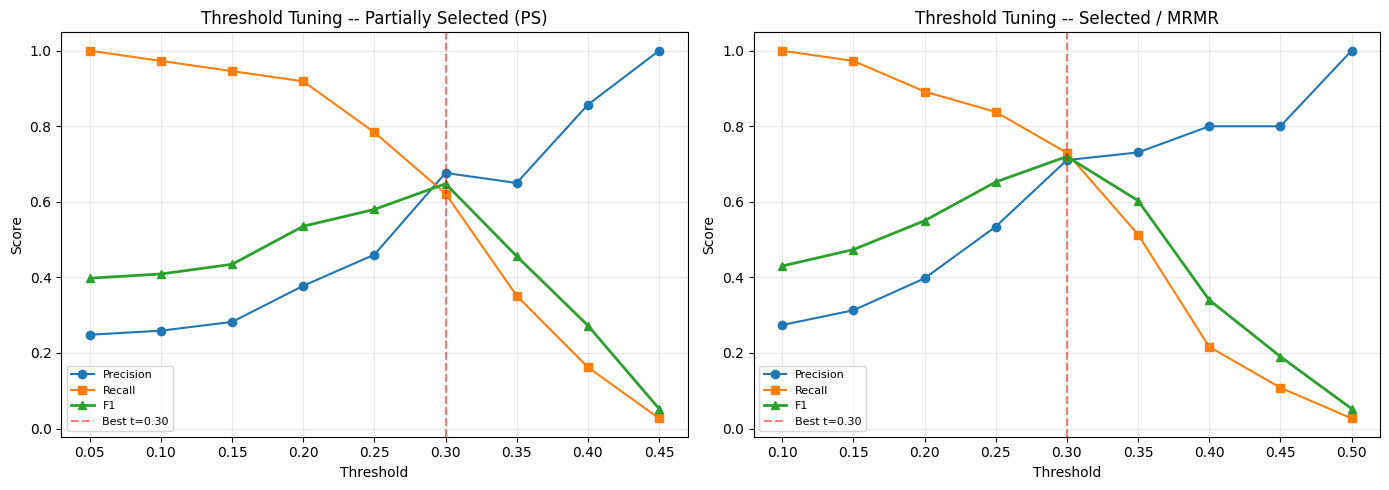

In [13]:
# Visualize threshold trade-off -- both feature sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds in zip(axes, datasets):
    t_df = ds['t_df']
    ax.plot(t_df['Threshold'], t_df['Precision'], 'o-', label='Precision')
    ax.plot(t_df['Threshold'], t_df['Recall'], 's-', label='Recall')
    ax.plot(t_df['Threshold'], t_df['F1'], '^-', label='F1', linewidth=2)
    ax.axvline(x=ds['best_threshold'], color='red', linestyle='--', alpha=0.5,
               label=f'Best t={ds["best_threshold"]:.2f}')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'Threshold Tuning -- {ds["label"]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Evaluate with best threshold on train + validation (test held out)
for ds in datasets:
    best_threshold = ds['best_threshold']
    print(f"\n{'='*60}")
    print(f"{ds['label']}  --  threshold = {best_threshold:.2f}")
    print(f"{'='*60}")

    for name, X_set, y_set in [('Train', ds['X_train'], ds['y_train']),
                                ('Validation', ds['X_val'], ds['y_val'])]:
        y_prob = predict_proba(ds['model_v2'], X_set)
        y_pred_t = (y_prob >= best_threshold).astype(int)
        res = evaluate_model(y_set, y_pred_t, y_prob)
        print_metrics(res, name)
        print()
        if name == 'Validation':
            ds['val_res_v3'] = res

    ds['results_log'].append({
        'Run': f'V3: Tuned + threshold={best_threshold:.2f}',
        'Val F1': ds['val_res_v3']['f1'],
        'Val Precision': ds['val_res_v3']['precision'],
        'Val Recall': ds['val_res_v3']['recall'],
        'Val ROC AUC': ds['val_res_v3']['roc_auc'],
    })


Partially Selected (PS)  --  threshold = 0.30


[Train] Accuracy:  0.7929
[Train] Precision: 0.5814
[Train] Recall:    0.5780
[Train] F1 Score:  0.5797
[Train] ROC AUC:   0.8191

[Validation] Accuracy:  0.8333
[Validation] Precision: 0.6765
[Validation] Recall:    0.6216
[Validation] F1 Score:  0.6479
[Validation] ROC AUC:   0.8252


Selected / MRMR  --  threshold = 0.30
[Train] Accuracy:  0.8243
[Train] Precision: 0.6276
[Train] Recall:    0.7110
[Train] F1 Score:  0.6667
[Train] ROC AUC:   0.8579

[Validation] Accuracy:  0.8600
[Validation] Precision: 0.7105
[Validation] Recall:    0.7297
[Validation] F1 Score:  0.7200
[Validation] ROC AUC:   0.8692



---## Run 8: SMOTE Comparison**Goal:** Test whether oversampling the minority class with SMOTE improves the best configuration.**Method:**- Apply SMOTE to the training set only (never to val/test)- Retrain the best KNN config on SMOTE-augmented training data- Compare val metrics with vs without SMOTE- Use the better one for final test evaluation

In [15]:
smote = SMOTE(random_state=42)

for ds in datasets:
    print(f"\n{'='*60}")
    print(f"SMOTE Comparison -- {ds['label']}")
    print(f"{'='*60}")

    # Apply SMOTE to training set only
    X_train_sm, y_train_sm = smote.fit_resample(ds['X_train'], ds['y_train'])
    print(f"Original train: {len(ds['y_train'])} (fraud={ds['y_train'].sum()})")
    print(f"SMOTE train:    {len(y_train_sm)} (fraud={y_train_sm.sum()})")

    # Train model with SMOTE data using best config
    model_smote = KNeighborsClassifier(
        n_neighbors=ds['best_k'], weights=ds['best_w'], metric=ds['best_met'], n_jobs=-1
    )
    model_smote.fit(X_train_sm, y_train_sm)

    # Evaluate on validation set with threshold tuning
    y_prob_val_smote = predict_proba(model_smote, ds['X_val'])
    bt_smote, bf_smote = find_best_threshold(ds['y_val'], y_prob_val_smote)

    y_pred_smote = (y_prob_val_smote >= bt_smote).astype(int)
    res_smote = evaluate_model(ds['y_val'], y_pred_smote, y_prob_val_smote)

    # Compare with non-SMOTE (V3 results)
    print(f"\nWithout SMOTE (threshold={ds['best_threshold']:.2f}):")
    print(f"  Val F1:      {ds['val_res_v3']['f1']:.4f}")
    print(f"  Val Prec:    {ds['val_res_v3']['precision']:.4f}")
    print(f"  Val Recall:  {ds['val_res_v3']['recall']:.4f}")
    print(f"  Val ROC AUC: {ds['val_res_v3']['roc_auc']:.4f}")

    print(f"\nWith SMOTE (threshold={bt_smote:.2f}):")
    print(f"  Val F1:      {res_smote['f1']:.4f}")
    print(f"  Val Prec:    {res_smote['precision']:.4f}")
    print(f"  Val Recall:  {res_smote['recall']:.4f}")
    print(f"  Val ROC AUC: {res_smote['roc_auc']:.4f}")

    # Pick the better one by Val F1
    if res_smote['f1'] > ds['val_res_v3']['f1']:
        ds['use_smote'] = True
        ds['final_model'] = model_smote
        ds['final_threshold'] = bt_smote
        ds['final_val_res'] = res_smote
        ds['X_train_final'] = X_train_sm
        ds['y_train_final'] = y_train_sm
        print(f"\n>>> SMOTE is BETTER. Using SMOTE model for final evaluation.")
    else:
        ds['use_smote'] = False
        ds['final_model'] = ds['model_v2']
        ds['final_threshold'] = ds['best_threshold']
        ds['final_val_res'] = ds['val_res_v3']
        ds['X_train_final'] = ds['X_train']
        ds['y_train_final'] = ds['y_train']
        print(f"\n>>> Non-SMOTE is BETTER (or equal). Using original model for final evaluation.")

    ds['results_log'].append({
        'Run': f'V4: SMOTE (threshold={bt_smote:.2f})',
        'Val F1': res_smote['f1'],
        'Val Precision': res_smote['precision'],
        'Val Recall': res_smote['recall'],
        'Val ROC AUC': res_smote['roc_auc'],
    })


SMOTE Comparison -- Partially Selected (PS)
Original train: 700 (fraud=173)
SMOTE train:    1054 (fraud=527)

Without SMOTE (threshold=0.30):
  Val F1:      0.6479
  Val Prec:    0.6765
  Val Recall:  0.6216
  Val ROC AUC: 0.8252

With SMOTE (threshold=0.50):
  Val F1:      0.5882
  Val Prec:    0.5208
  Val Recall:  0.6757
  Val ROC AUC: 0.8090

>>> Non-SMOTE is BETTER (or equal). Using original model for final evaluation.

SMOTE Comparison -- Selected / MRMR
Original train: 700 (fraud=173)
SMOTE train:    1054 (fraud=527)

Without SMOTE (threshold=0.30):
  Val F1:      0.7200
  Val Prec:    0.7105
  Val Recall:  0.7297
  Val ROC AUC: 0.8692

With SMOTE (threshold=0.50):
  Val F1:      0.6279
  Val Prec:    0.5510
  Val Recall:  0.7297
  Val ROC AUC: 0.8115

>>> Non-SMOTE is BETTER (or equal). Using original model for final evaluation.


---## Run Summary & Model SelectionCompare all experiment runs on **validation metrics only** for each feature set.

In [16]:
for ds in datasets:
    summary_df = pd.DataFrame(ds['results_log'])
    ds['summary_df'] = summary_df

    print(f"\n{'='*90}")
    print(f"EXPERIMENT LOG -- {ds['label']}")
    print(f"{'='*90}")
    print(summary_df.to_string(index=False))

    best_idx = summary_df['Val F1'].idxmax()
    ds['best_run_name'] = summary_df.loc[best_idx, 'Run']
    print(f"\nBest run by Val F1: {ds['best_run_name']}")
    print(f"  Val F1:        {summary_df.loc[best_idx, 'Val F1']:.4f}")
    print(f"  Val Precision: {summary_df.loc[best_idx, 'Val Precision']:.4f}")
    print(f"  Val Recall:    {summary_df.loc[best_idx, 'Val Recall']:.4f}")
    print(f"  Val ROC AUC:   {summary_df.loc[best_idx, 'Val ROC AUC']:.4f}")


EXPERIMENT LOG -- Partially Selected (PS)
                                   Run   Val F1  Val Precision  Val Recall  Val ROC AUC
V1: Baseline (K=5, uniform, euclidean) 0.264151       0.437500    0.189189     0.633222
  V2: Tuned (K=51, uniform, manhattan) 0.000000       0.000000    0.000000     0.825161
            V3: Tuned + threshold=0.30 0.647887       0.676471    0.621622     0.825161
            V4: SMOTE (threshold=0.50) 0.588235       0.520833    0.675676     0.809017

Best run by Val F1: V3: Tuned + threshold=0.30
  Val F1:        0.6479
  Val Precision: 0.6765
  Val Recall:    0.6216
  Val ROC AUC:   0.8252

EXPERIMENT LOG -- Selected / MRMR
                                   Run   Val F1  Val Precision  Val Recall  Val ROC AUC
V1: Baseline (K=5, uniform, euclidean) 0.250000       0.368421    0.189189     0.604401
  V2: Tuned (K=51, uniform, manhattan) 0.052632       1.000000    0.027027     0.869170
            V3: Tuned + threshold=0.30 0.720000       0.710526    0.729730

---## Cross-Dataset Comparison (Validation Only)Side-by-side comparison of the best run from each feature set.

In [17]:
comparison_rows = []
for ds in datasets:
    best_idx = ds['summary_df']['Val F1'].idxmax()
    row = ds['summary_df'].iloc[best_idx].to_dict()
    row['Feature Set'] = ds['label']
    row['SMOTE'] = ds['use_smote']
    comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
print("="*90)
print("BEST MODEL COMPARISON -- Partially Selected vs Selected/MRMR")
print("="*90)
print(comp_df.to_string(index=False))

BEST MODEL COMPARISON -- Partially Selected vs Selected/MRMR
                       Run   Val F1  Val Precision  Val Recall  Val ROC AUC             Feature Set  SMOTE
V3: Tuned + threshold=0.30 0.647887       0.676471    0.621622     0.825161 Partially Selected (PS)  False
V3: Tuned + threshold=0.30 0.720000       0.710526    0.729730     0.869170         Selected / MRMR  False


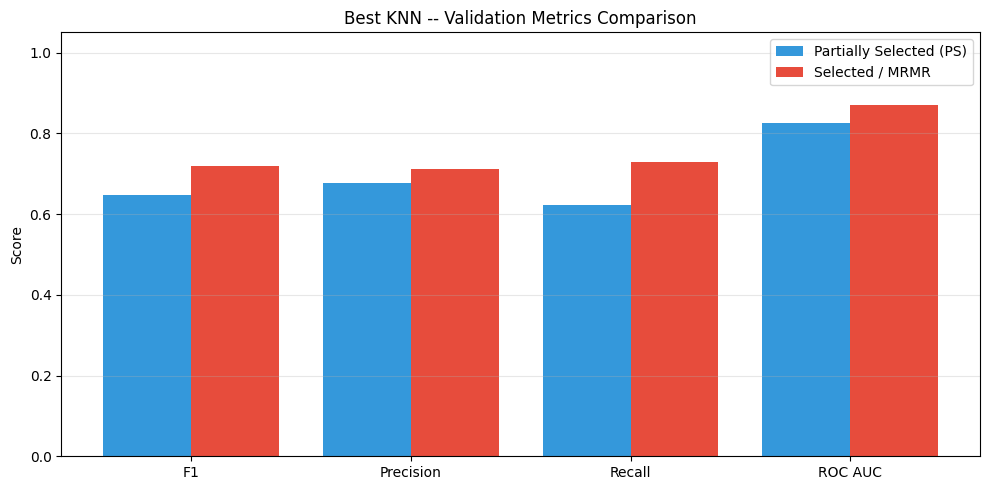

In [18]:
# Visual comparison -- bar chart of validation metrics
metrics = ['Val F1', 'Val Precision', 'Val Recall', 'Val ROC AUC']
metric_labels = ['F1', 'Precision', 'Recall', 'ROC AUC']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

x = np.arange(len(metrics))
n_bars = len(comp_df)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row['Feature Set'], color=bar_colors[i % len(bar_colors)])

ax.set_xticks(x + width * (n_bars - 1) / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Score')
ax.set_title('Best KNN -- Validation Metrics Comparison')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---## Final Test Evaluation (ONE-TIME)**This is the only place in the notebook where the test set is used.**After all hyperparameter tuning and model selection on the validation set, we evaluate thebest configuration on the held-out test set exactly once for each feature set.The model used may be SMOTE-augmented or not, depending on which performed better on validation.

In [19]:
for ds in datasets:
    threshold = ds['final_threshold']

    print(f"\n{'='*60}")
    print(f"FINAL TEST -- {ds['label']}")
    print(f"{'='*60}")
    print(f"Model: KNN(K={ds['best_k']}, weights={ds['best_w']}, metric={ds['best_met']})")
    print(f"Threshold: {threshold:.2f}")
    print(f"SMOTE: {ds['use_smote']}\n")

    y_prob_test = predict_proba(ds['final_model'], ds['X_test'])
    y_pred_test = (y_prob_test >= threshold).astype(int)
    test_res = evaluate_model(ds['y_test'], y_pred_test, y_prob_test)
    print_metrics(test_res, 'Test')

    print("\nClassification Report:")
    print(classification_report(ds['y_test'], y_pred_test, target_names=['Non-Fraud', 'Fraud']))

    ds['test_res'] = test_res
    ds['y_prob_test'] = y_prob_test
    ds['y_pred_test'] = y_pred_test


FINAL TEST -- Partially Selected (PS)
Model: KNN(K=51, weights=uniform, metric=manhattan)
Threshold: 0.30
SMOTE: False

[Test] Accuracy:  0.7733
[Test] Precision: 0.5455
[Test] Recall:    0.4865
[Test] F1 Score:  0.5143
[Test] ROC AUC:   0.6923

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.84      0.87      0.85       113
       Fraud       0.55      0.49      0.51        37

    accuracy                           0.77       150
   macro avg       0.69      0.68      0.68       150
weighted avg       0.77      0.77      0.77       150


FINAL TEST -- Selected / MRMR
Model: KNN(K=51, weights=uniform, metric=manhattan)
Threshold: 0.30
SMOTE: False

[Test] Accuracy:  0.7600
[Test] Precision: 0.5152
[Test] Recall:    0.4595
[Test] F1 Score:  0.4857
[Test] ROC AUC:   0.7584

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.83      0.86      0.84       113
       Fraud       0.52      0.4

In [20]:
# Test set comparison table
print("="*80)
print("FINAL TEST COMPARISON -- Partially Selected vs Selected/MRMR")
print("="*80)

test_comp = []
for ds in datasets:
    test_comp.append({
        'Feature Set': ds['label'],
        'SMOTE': ds['use_smote'],
        'Test F1': ds['test_res']['f1'],
        'Test Precision': ds['test_res']['precision'],
        'Test Recall': ds['test_res']['recall'],
        'Test ROC AUC': ds['test_res']['roc_auc'],
        'Test Accuracy': ds['test_res']['accuracy'],
    })

test_comp_df = pd.DataFrame(test_comp)
print(test_comp_df.to_string(index=False))

for i in range(len(test_comp_df)):
    for j in range(i+1, len(test_comp_df)):
        r1, r2 = test_comp_df.iloc[i], test_comp_df.iloc[j]
        print(f"\nDelta ({r1['Feature Set'][:15]} vs {r2['Feature Set'][:15]}):")
        for m in ['Test F1', 'Test Precision', 'Test Recall', 'Test ROC AUC', 'Test Accuracy']:
            delta = r1[m] - r2[m]
            sign = '+' if delta >= 0 else ''
            print(f"  {m}: {sign}{delta:.4f}")

FINAL TEST COMPARISON -- Partially Selected vs Selected/MRMR
            Feature Set  SMOTE  Test F1  Test Precision  Test Recall  Test ROC AUC  Test Accuracy
Partially Selected (PS)  False 0.514286        0.545455     0.486486      0.692298       0.773333
        Selected / MRMR  False 0.485714        0.515152     0.459459      0.758431       0.760000

Delta (Partially Selec vs Selected / MRMR):
  Test F1: +0.0286
  Test Precision: +0.0303
  Test Recall: +0.0270
  Test ROC AUC: -0.0661
  Test Accuracy: +0.0133


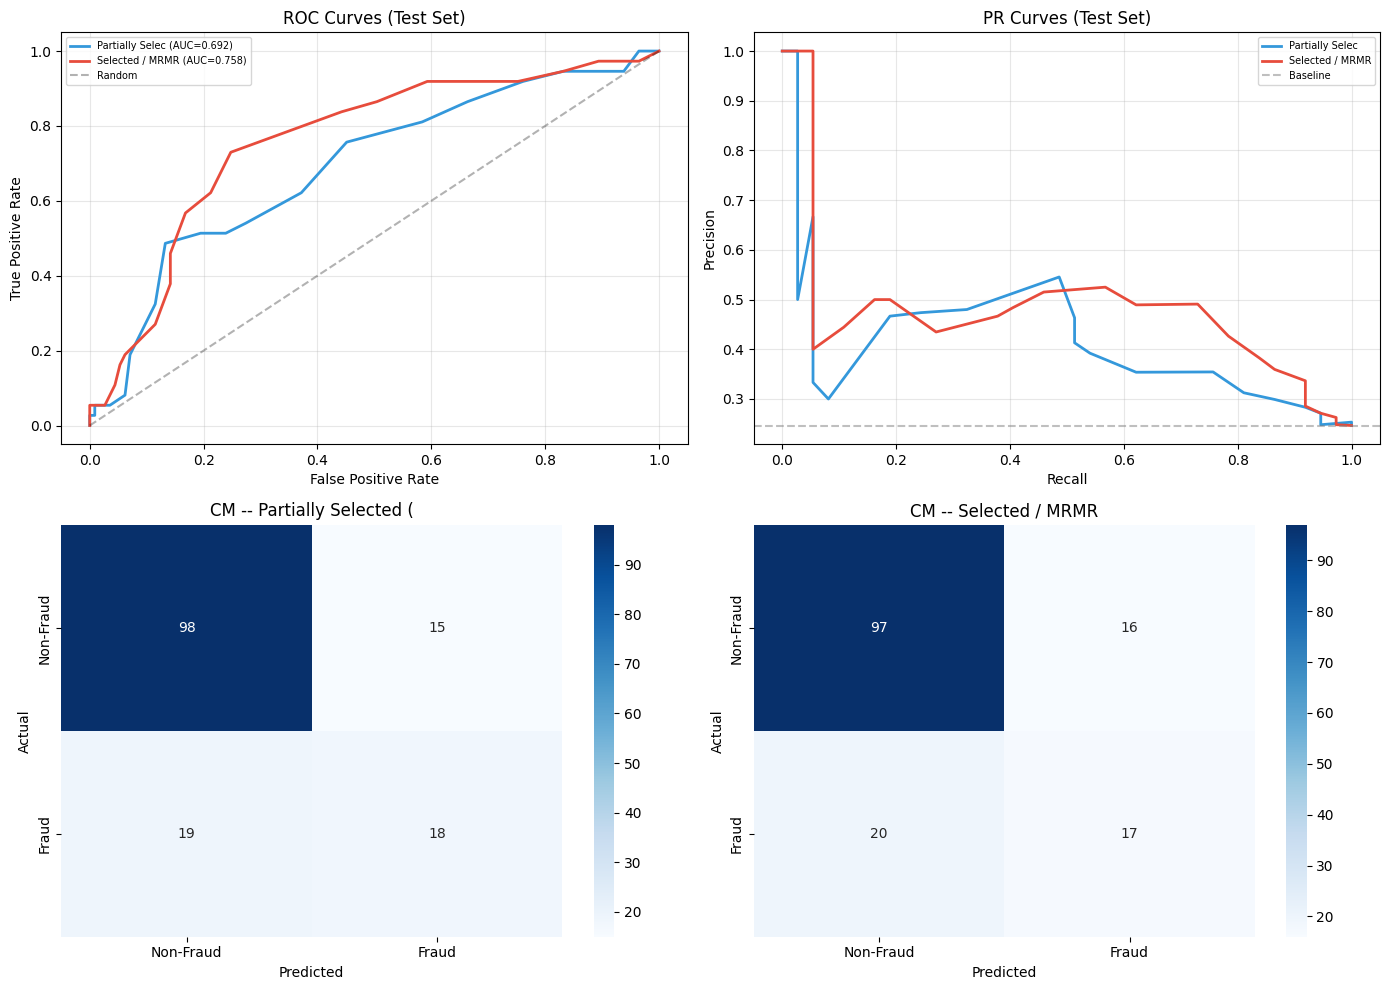

In [21]:
# Final visualizations -- ROC, PR curve, confusion matrices
n_ds = len(datasets)
fig, axes = plt.subplots(2, max(n_ds, 2), figsize=(7*max(n_ds, 2), 10))
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Row 0: ROC + PR
for i, ds in enumerate(datasets):
    fpr, tpr, _ = roc_curve(ds['y_test'], ds['y_prob_test'])
    roc_auc_val = auc(fpr, tpr)
    axes[0, 0].plot(fpr, tpr, color=colors[i], linewidth=2,
                    label=f'{ds["label"][:15]} (AUC={roc_auc_val:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0, 0].set_xlabel('False Positive Rate'); axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves (Test Set)'); axes[0, 0].legend(fontsize=7); axes[0, 0].grid(True, alpha=0.3)

for i, ds in enumerate(datasets):
    prec, rec, _ = precision_recall_curve(ds['y_test'], ds['y_prob_test'])
    axes[0, 1].plot(rec, prec, color=colors[i], linewidth=2, label=ds['label'][:15])
axes[0, 1].axhline(y=datasets[0]['y_test'].mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('PR Curves (Test Set)'); axes[0, 1].legend(fontsize=7); axes[0, 1].grid(True, alpha=0.3)

for j in range(2, max(n_ds, 2)):
    axes[0, j].set_visible(False)

# Row 1: Confusion matrices
for i, ds in enumerate(datasets):
    cm = confusion_matrix(ds['y_test'], ds['y_pred_test'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, i],
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    axes[1, i].set_title(f'CM -- {ds["label"][:20]}')
    axes[1, i].set_ylabel('Actual'); axes[1, i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

---## Save Best ModelSave the overall best KNN model (by test F1) along with metadata needed for inference.

In [22]:
# Select the best dataset by test F1
best_ds = max(datasets, key=lambda d: d['test_res']['f1'])

print(f"Best overall model: {best_ds['label']}")
print(f"  K={best_ds['best_k']}, weights={best_ds['best_w']}, metric={best_ds['best_met']}")
print(f"  Threshold: {best_ds['final_threshold']:.2f}")
print(f"  SMOTE: {best_ds['use_smote']}")
print(f"  Test F1: {best_ds['test_res']['f1']:.4f}")

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# Save the model
joblib.dump(best_ds['final_model'], '../models/best_knn.joblib')
print("\nModel saved to ../models/best_knn.joblib")

# Save metadata
meta = {
    'feature_names': best_ds['feature_names'],
    'threshold': float(best_ds['final_threshold']),
    'use_smote': best_ds['use_smote'],
    'scaler': best_ds['scaler'],
    'val_metrics': {
        'f1': float(best_ds['final_val_res']['f1']),
        'precision': float(best_ds['final_val_res']['precision']),
        'recall': float(best_ds['final_val_res']['recall']),
        'roc_auc': float(best_ds['final_val_res']['roc_auc']),
        'accuracy': float(best_ds['final_val_res']['accuracy']),
    },
    'test_metrics': {
        'f1': float(best_ds['test_res']['f1']),
        'precision': float(best_ds['test_res']['precision']),
        'recall': float(best_ds['test_res']['recall']),
        'roc_auc': float(best_ds['test_res']['roc_auc']),
        'accuracy': float(best_ds['test_res']['accuracy']),
    },
    'hyperparameters': {
        'n_neighbors': best_ds['best_k'],
        'weights': best_ds['best_w'],
        'metric': best_ds['best_met'],
    },
    'feature_set': best_ds['label'],
}
joblib.dump(meta, '../models/best_knn_meta.joblib')
print("Metadata saved to ../models/best_knn_meta.joblib")
print(f"\nMetadata keys: {list(meta.keys())}")
print(f"Number of features: {len(meta['feature_names'])}")

Best overall model: Partially Selected (PS)
  K=51, weights=uniform, metric=manhattan
  Threshold: 0.30
  SMOTE: False
  Test F1: 0.5143

Model saved to ../models/best_knn.joblib
Metadata saved to ../models/best_knn_meta.joblib

Metadata keys: ['feature_names', 'threshold', 'use_smote', 'scaler', 'val_metrics', 'test_metrics', 'hyperparameters', 'feature_set']
Number of features: 162
